<a href="https://colab.research.google.com/github/vtu27065/Deep-Learning/blob/main/Task_1_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Binary Classification of Grayscale Images using PyTorch

## Aim
To implement a binary classification model for grayscale images using
the PyTorch deep learning framework.

## Dataset
MNIST handwritten digit dataset.

## Binary Classes
- Class 0 → Digits 0, 1, 2, 3, 4
- Class 1 → Digits 5, 6, 7, 8, 9

## Model
Convolutional Neural Network (CNN)

## Framework
PyTorch

In [9]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PyTorch version: 2.11.0+cu128
GPU available: True
Device: cuda


In [10]:
# PyTorch is the main deep learning framework
import torch

# torch.nn contains neural network layers such as
# Conv2D, Linear, ReLU, etc.
import torch.nn as nn

# optim provides optimization algorithms such as Adam
import torch.optim as optim

# torchvision provides ready-made image datasets
# and image transformation functions
from torchvision import datasets, transforms

# DataLoader helps us load images in batches
from torch.utils.data import DataLoader

print("Libraries imported successfully")

Libraries imported successfully


In [11]:
# Check whether Google Colab has provided a GPU
print("GPU Available:", torch.cuda.is_available())

# Select GPU if available; otherwise use CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

GPU Available: True
Using device: cuda


In [12]:
# MNIST images are grayscale images of size 28 × 28.

# ToTensor():
# Converts the image into a PyTorch tensor.
#
# Normalize():
# Normalizes pixel values so that training becomes
# more stable and efficient.

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print("Image transformation defined")

Image transformation defined


The `train_data` variable appears to be undefined, even though the cell for it previously executed. This can happen if the kernel state was reset. Let's re-run the data loading step to ensure `train_data` and `test_data` are properly initialized.

In [13]:
# Download the training dataset
train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Download the testing dataset
test_data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.08MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.3MB/s]

Training samples: 60000
Testing samples: 10000


In [14]:
# Download the training dataset
train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Download the testing dataset
test_data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))

Training samples: 60000
Testing samples: 10000


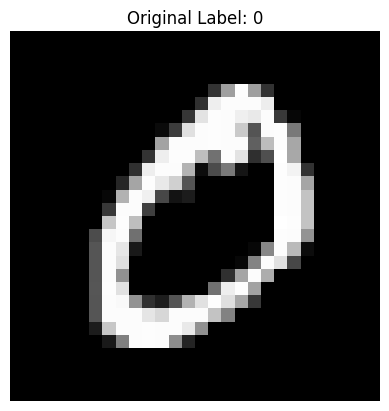

In [15]:
import matplotlib.pyplot as plt

# Get one image and its label
image, label = train_data[1]

# Display the image
plt.imshow(image.squeeze(), cmap="gray")

plt.title(f"Original Label: {label}")

plt.axis("off")
plt.show()

In [16]:
class BinaryMNIST(torch.utils.data.Dataset):

    def __init__(self, dataset):
        # Store the original MNIST dataset
        self.dataset = dataset

    def __len__(self):
        # Return number of images
        return len(self.dataset)

    def __getitem__(self, index):

        # Get image and original digit label
        image, label = self.dataset[index]

        # Convert 10 classes into 2 classes
        #
        # Digits 0-4 → Class 0
        # Digits 5-9 → Class 1
        if label < 5:
            label = 0
        else:
            label = 1

        return image, torch.tensor(
            label,
            dtype=torch.float32
        )

In [17]:
# Convert the original MNIST datasets
# into binary classification datasets.

train_dataset = BinaryMNIST(train_data)
test_dataset = BinaryMNIST(test_data)

print("Binary training dataset created")
print("Binary testing dataset created")

Binary training dataset created
Binary testing dataset created


In [18]:
# Batch size determines how many images
# are processed at one time.

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("DataLoaders created successfully")

DataLoaders created successfully


In [19]:
# Get the first batch from the training DataLoader
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


In [21]:
class BinaryCNN(nn.Module):

    def __init__(self):
        super().__init__()

        # Feature extraction section
        self.features = nn.Sequential(

            # Input:
            # 1 × 28 × 28
            #
            # 1 input channel because image is grayscale
            # 16 filters are used to extract features
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),

            # Introduces non-linearity
            nn.ReLU(),

            # Reduces spatial size by half
            nn.MaxPool2d(2),

            # Second convolution layer
            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        # Classification section
        self.classifier = nn.Sequential(

            # Convert feature maps into one-dimensional vector
            nn.Flatten(),

            # Fully connected layer
            nn.Linear(32 * 7 * 7, 64),

            nn.ReLU(),

            # Final output

            # Only ONE neuron because this is binary classification
            nn.Linear(64, 1)
        )

    def forward(self, x):

        # Extract image features
        x = self.features(x)

        # Perform classification
        x = self.classifier(x)

        return x

### CNN Dimensions

Input Image:
1 × 28 × 28

After Conv2D:
16 × 28 × 28

After MaxPool:
16 × 14 × 14

After Conv2D:
32 × 14 × 14

After MaxPool:
32 × 7 × 7

After Flatten:
32 × 7 × 7 = 1568

In [22]:
# Create an object of our CNN model
model = BinaryCNN()

# Move the model to GPU if available
model = model.to(device)

# Display the model architecture
print(model)

BinaryCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [23]:
# BCE = Binary Cross Entropy
#
# This loss function is suitable for
# binary classification problems.

criterion = nn.BCEWithLogitsLoss()

print("Loss function:", criterion)

Loss function: BCEWithLogitsLoss()


In [24]:
# Adam updates the weights of the neural network
# during training.

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [25]:
epochs = 5

for epoch in range(epochs):

    # Put model into training mode
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    # Process training data batch-by-batch
    for images, labels in train_loader:

        # Move data to GPU/CPU
        images = images.to(device)
        labels = labels.to(device)

        # Change labels from:
        # [64]
        # to:
        # [64, 1]
        labels = labels.view(-1, 1)

        # -----------------------------
        # Forward Propagation
        # -----------------------------
        outputs = model(images)

        # -----------------------------
        # Calculate Loss
        # -----------------------------
        loss = criterion(outputs, labels)

        # -----------------------------
        # Backpropagation
        # -----------------------------

        # Remove previous gradients
        optimizer.zero_grad()

        # Calculate new gradients
        loss.backward()

        # Update model weights
        optimizer.step()

        total_loss += loss.item()

        # Convert output into probability
        probabilities = torch.sigmoid(outputs)

        # Probability >= 0.5 → Class 1
        # Probability < 0.5  → Class 0
        predictions = (
            probabilities >= 0.5
        ).float()

        # Calculate correct predictions
        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {total_loss/len(train_loader):.4f} "
        f"Accuracy: {accuracy:.2f}%"
    )

Epoch [1/5] Loss: 0.1484 Accuracy: 94.00%
Epoch [2/5] Loss: 0.0522 Accuracy: 98.15%
Epoch [3/5] Loss: 0.0352 Accuracy: 98.79%
Epoch [4/5] Loss: 0.0274 Accuracy: 99.12%
Epoch [5/5] Loss: 0.0223 Accuracy: 99.26%


### Training Process

For every batch:

1. Input images are given to CNN.
2. CNN performs forward propagation.
3. Model produces an output.
4. Loss is calculated using BCEWithLogitsLoss.
5. Gradients are calculated using backward propagation.
6. Adam optimizer updates the model weights.
7. Predictions are generated using a threshold of 0.5.
8. Accuracy is calculated.

Flow:

Image
↓
CNN
↓
Output Logit
↓
Sigmoid
↓
Probability
↓
Threshold = 0.5
↓
Class 0 / Class 1

In [26]:
# Switch model to evaluation mode
model.eval()

correct = 0
total = 0

# No gradients are required during testing
with torch.no_grad():

    for images, labels in test_loader:

        # Move data to GPU/CPU
        images = images.to(device)
        labels = labels.to(device)

        labels = labels.view(-1, 1)

        # Forward propagation
        outputs = model(images)

        # Convert logits into probabilities
        probabilities = torch.sigmoid(outputs)

        # Convert probability to class
        predictions = (
            probabilities >= 0.5
        ).float()

        # Count correct predictions
        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

# Calculate test accuracy
test_accuracy = 100 * correct / total

print(
    f"Test Accuracy: {test_accuracy:.2f}%"
)

Test Accuracy: 98.93%


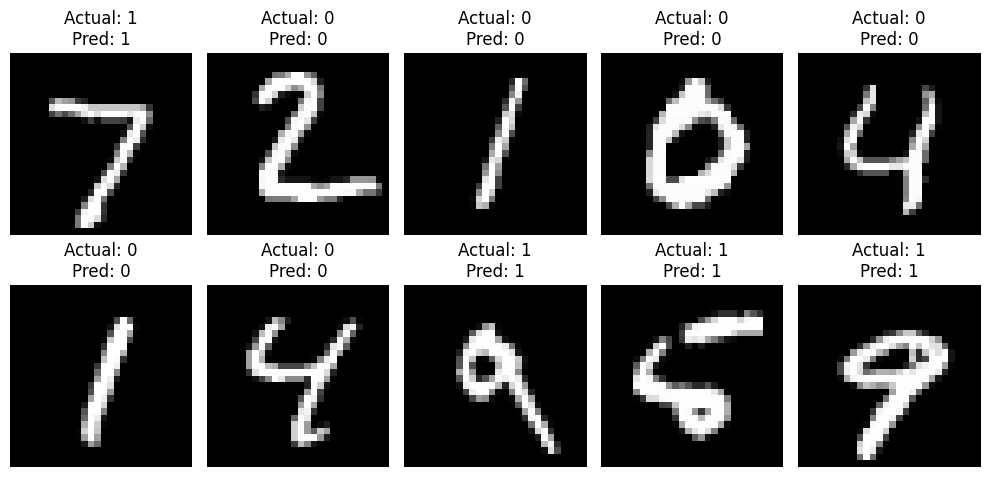

In [27]:
import matplotlib.pyplot as plt

# Get one batch from test data
images, labels = next(iter(test_loader))

# Move images to device
images = images.to(device)

# Disable gradient calculation
with torch.no_grad():

    outputs = model(images)

    probabilities = torch.sigmoid(outputs)

    predictions = (
        probabilities >= 0.5
    ).float()

# Display first 10 images
plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        images[i].cpu().squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Actual: {int(labels[i])}\n"
        f"Pred: {int(predictions[i])}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## Result

Thus, a binary classification model for grayscale images was
successfully implemented using a Convolutional Neural Network
with the PyTorch framework.

The MNIST dataset was converted from a 10-class problem into
a binary classification problem:

- Class 0 → Digits 0–4
- Class 1 → Digits 5–9

The trained CNN model was evaluated using test accuracy.

# Draw in Canvas

In [29]:
from IPython.display import HTML, display

display(HTML("""
<canvas id="canvas" width="280" height="280"
        style="border:2px solid black; background:white;">
</canvas>

<br><br>

<button onclick="clearCanvas()">Clear</button>

<script>
var canvas = document.getElementById("canvas");
var ctx = canvas.getContext("2d");

ctx.fillStyle = "white";
ctx.fillRect(0, 0, canvas.width, canvas.height);

ctx.strokeStyle = "black";
ctx.lineWidth = 18;
ctx.lineCap = "round";

var drawing = false;

canvas.addEventListener("mousedown", function(e) {
    drawing = true;
    ctx.beginPath();
    ctx.moveTo(e.offsetX, e.offsetY);
});

canvas.addEventListener("mousemove", function(e) {
    if (drawing) {
        ctx.lineTo(e.offsetX, e.offsetY);
        ctx.stroke();
    }
});

canvas.addEventListener("mouseup", function() {
    drawing = false;
});

canvas.addEventListener("mouseleave", function() {
    drawing = false;
});

function clearCanvas() {
    ctx.fillStyle = "white";
    ctx.fillRect(0, 0, canvas.width, canvas.height);
}
</script>
"""))